In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

class LogisticRegressionCustom:
    def __init__(self, learning_rate=0.01, iterations=1000, regularization=None, reg_strength=0.1, multiclass='ovr'):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.regularization = regularization  # None, 'l1', 'l2'
        self.reg_strength = reg_strength
        self.multiclass = multiclass  # 'ovr' or 'softmax'
        self.loss_history = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def _softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # numerical stability
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _loss(self, y_true, y_pred, weights):
        n = y_true.shape[0]
        if self.multiclass == 'softmax':
            log_likelihood = -np.log(y_pred[range(n), y_true])
            loss = np.sum(log_likelihood) / n
        else:
            loss = -(1/n) * np.sum(y_true * np.log(y_pred + 1e-15) + (1 - y_true) * np.log(1 - y_pred + 1e-15))

        if self.regularization == 'l1':
            loss += self.reg_strength * np.sum(np.abs(weights))
        elif self.regularization == 'l2':
            loss += self.reg_strength * np.sum(weights ** 2)

        return loss

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape
        self.classes = np.unique(y)

        if len(self.classes) == 2 and self.multiclass != 'softmax':
            self.weights = np.zeros(n_features)
            self.bias = 0
            self._fit_binary(X, y)
        else:
            if self.multiclass == 'ovr':
                self.class_weights = {}
                for cls in self.classes:
                    y_binary = (y == cls).astype(int)
                    model = LogisticRegressionCustom(self.learning_rate, self.iterations, self.regularization, self.reg_strength)
                    model.fit(X, y_binary)
                    self.class_weights[cls] = (model.weights, model.bias)
            elif self.multiclass == 'softmax':
                self.weights = np.zeros((len(self.classes), n_features))
                self.bias = np.zeros(len(self.classes))
                self._fit_softmax(X, y)

    def _fit_binary(self, X, y):
        for i in range(self.iterations):
            linear = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(linear)

            dw = (1/X.shape[0]) * np.dot(X.T, (y_pred - y))
            db = (1/X.shape[0]) * np.sum(y_pred - y)

            if self.regularization == 'l1':
                dw += self.reg_strength * np.sign(self.weights)
            elif self.regularization == 'l2':
                dw += self.reg_strength * self.weights

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            loss = self._loss(y, y_pred, self.weights)
            self.loss_history.append(loss)

    def _fit_softmax(self, X, y):
        y_one_hot = np.eye(len(self.classes))[y]
        for i in range(self.iterations):
            logits = np.dot(X, self.weights.T) + self.bias
            y_pred = self._softmax(logits)

            error = y_pred - y_one_hot
            dw = (1/X.shape[0]) * np.dot(error.T, X)
            db = (1/X.shape[0]) * np.sum(error, axis=0)

            if self.regularization == 'l2':
                dw += self.reg_strength * self.weights

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            loss = self._loss(y, y_pred, self.weights)
            self.loss_history.append(loss)

    def predict_proba(self, X):
        if hasattr(self, 'class_weights'):
            probs = []
            for cls in self.classes:
                w, b = self.class_weights[cls]
                logits = np.dot(X, w) + b
                probs.append(self._sigmoid(logits))
            return np.vstack(probs).T
        elif hasattr(self, 'weights') and self.weights.ndim == 2:  # softmax
            logits = np.dot(X, self.weights.T) + self.bias
            return self._softmax(logits)
        else:
            linear = np.dot(X, self.weights) + self.bias
            return self._sigmoid(linear)

    def predict(self, X):
        proba = self.predict_proba(X)
        if hasattr(self, 'class_weights') or (hasattr(self, 'weights') and self.weights.ndim == 2):
            return np.argmax(proba, axis=1)
        return (proba >= 0.5).astype(int)

    def plot_loss(self):
        plt.plot(range(len(self.loss_history)), self.loss_history)
        plt.title("Loss Curve During Training")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.show()


In [14]:
import pandas as pd
import numpy as np
product_df = pd.read_pickle('product_df.pkl')
product_df.head()

,parent_asin,embedding,product_category
0,0007176015,"[-0.08437212, 0.048469327, -0.041887764, 0.031...",Books
1,0007486774,"[-0.11107975, -0.026078232, 0.009338618, 0.038...",Books
2,0008119090,"[-0.06748395, -0.05149792, 0.011569342, 0.0136...",Books
3,0008322201,"[0.022111995, -0.10669361, -0.021940256, 0.056...",Books
4,0008390800,"[-0.024403963, -0.014026065, 0.006576489, 0.06...",Books


In [15]:
# Now extract features and labels
X_product = np.vstack(product_df['embedding'].values)
y_product = product_df['product_category'].values

In [16]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, make_scorer, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Encode the labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_product)

# Split data into training and hold-out test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_product, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)


Custom Logistic Regression Accuracy: 0.6396039603960396

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       744
           1       0.70      0.93      0.80       979
           2       0.55      0.89      0.68       961
           3       0.93      0.57      0.71       902
           4       0.55      0.65      0.60       959

    accuracy                           0.64      4545
   macro avg       0.55      0.61      0.56      4545
weighted avg       0.57      0.64      0.58      4545



d:\miniconda\envs\data_engineering\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\miniconda\envs\data_engineering\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\miniconda\envs\data_engineering\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


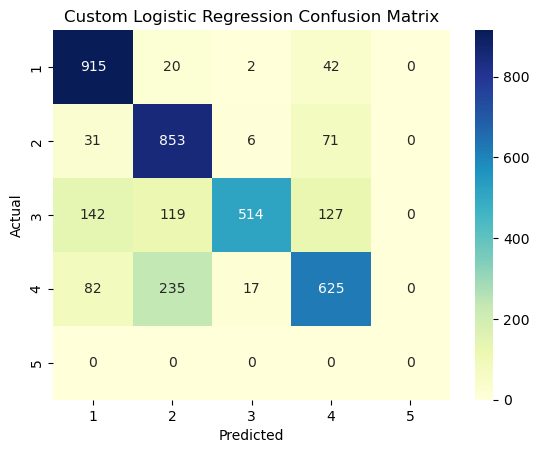

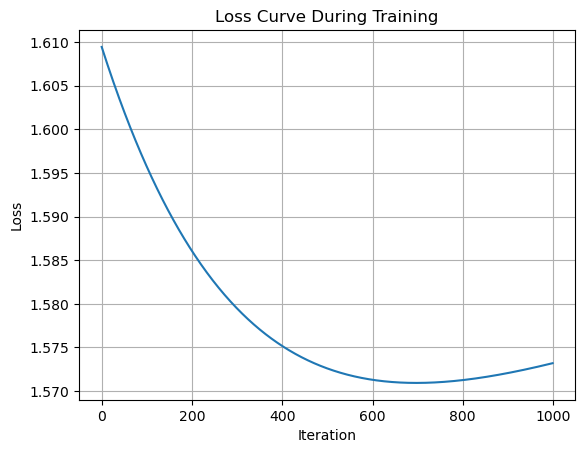

In [17]:
# Train custom logistic regression (OvR by default)
custom_model = LogisticRegressionCustom(
    learning_rate=0.01,
    iterations=1000,
    regularization='l2',
    reg_strength=0.1,
    multiclass='softmax'  # or 'softmax'
)

custom_model.fit(X_train, y_train)

y_pred_custom = custom_model.predict(X_test)


from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Custom Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_custom))
print("\nClassification Report:\n", classification_report(y_test, y_pred_custom))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_custom, labels=[1, 2, 3, 4, 5])
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Custom Logistic Regression Confusion Matrix")
plt.show()

# Optional: plot training loss
custom_model.plot_loss()
